### Modelos baseline de Machine Learning

Este notebook tem como objetivo preparar os dados para modelagem e treinar os primeiros modelos clássicos de Machine Learning.

A ideia desta etapa é criar uma base de comparação, também chamada de `baseline`, antes de avançar para modelos de Deep Learning e Quantum Machine Learning.

Neste notebook, vamos trabalhar com:

- tratamento de valores ausentes;
- separação entre variáveis de entrada e variável-alvo;
- divisão entre treino e teste;
- normalização dos dados;
- treinamento de modelos clássicos;
- avaliação com métricas adequadas para classificação.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/koi_selected_initial.csv")

df.head()

,kepid,kepoi_name,koi_disposition,koi_period,koi_duration,koi_depth,koi_num_transits,koi_model_snr,koi_prad,koi_teq,koi_insol,koi_steff,koi_slogg,koi_srad,koi_smass,koi_kepmag,ra,dec
0,10797460,K00752.01,CONFIRMED,9.488036,2.95750,615.8,142.0,35.8,2.26,793.0,93.59,5455.0,4.467,0.927,0.919,15.347,291.93423,48.141651
1,10797460,K00752.02,CONFIRMED,54.418383,4.50700,874.8,25.0,25.8,2.83,443.0,9.11,5455.0,4.467,0.927,0.919,15.347,291.93423,48.141651
2,10811496,K00753.01,CANDIDATE,19.899140,1.78220,10829.0,56.0,76.3,14.60,638.0,39.30,5853.0,4.544,0.868,0.961,15.436,297.00482,48.134129
3,10848459,K00754.01,FALSE POSITIVE,1.736952,2.40641,8079.2,621.0,505.6,33.46,1395.0,891.96,5805.0,4.564,0.791,0.836,15.597,285.53461,48.285210
4,10854555,K00755.01,CONFIRMED,2.525592,1.65450,603.3,515.0,40.9,2.75,1406.0,926.16,6031.0,4.438,1.046,1.095,15.509,288.75488,48.226200


### Separação das variáveis de entrada e da variável-alvo

In [3]:
target_column = "koi_disposition"

identifier_columns = [
    "kepid",
    "kepoi_name"
]

feature_columns = [
    column for column in df.columns
    if column not in identifier_columns + [target_column]
]

X = df[feature_columns].copy()
y = df[target_column].copy()

print("Quantidade de variáveis de entrada:", X.shape[1])
print("Quantidade de registros:", X.shape[0])
print("Variável-alvo:", target_column)

Quantidade de variáveis de entrada: 15
Quantidade de registros: 9564
Variável-alvo: koi_disposition


### Verificação de valores ausentes nas variáveis de entrada

In [4]:
X.isna().sum().sort_values(ascending=False)

koi_num_transits    1142
koi_depth            363
koi_model_snr        363
koi_prad             363
koi_teq              363
koi_steff            363
koi_slogg            363
koi_srad             363
koi_smass            363
koi_insol            321
koi_kepmag             1
koi_period             0
koi_duration           0
ra                     0
dec                    0
dtype: int64

### Tratamento de valores ausentes com mediana

In [5]:
X = X.fillna(X.median())

X.isna().sum().sum()

np.int64(0)

### Codificação da variável-alvo

In [7]:
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 25.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 39.2 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

class_mapping

{'CANDIDATE': np.int64(0),
 'CONFIRMED': np.int64(1),
 'FALSE POSITIVE': np.int64(2)}

### Análise da codificação da variável-alvo

A variável-alvo `koi_disposition` foi transformada de texto para número usando `LabelEncoder`.

Esse processo é necessário porque os modelos de Machine Learning trabalham melhor com valores numéricos. Cada classe recebeu um código:

- `CANDIDATE`: 0
- `CONFIRMED`: 1
- `FALSE POSITIVE`: 2

Essa transformação não muda o significado das classes. Ela apenas adapta os rótulos para que possam ser usados pelos algoritmos de classificação.

### Separação entre treino e teste

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7651, 15)
X_test: (1913, 15)
y_train: (7651,)
y_test: (1913,)


### Análise da separação entre treino e teste

Os dados foram separados em treino e teste usando a proporção de 80% para treinamento e 20% para teste.

O conjunto de treino ficou com 7.651 registros, enquanto o conjunto de teste ficou com 1.913 registros. Essa divisão permite treinar os modelos em uma parte dos dados e avaliar o desempenho em dados que o modelo ainda não viu.

Também foi usado o parâmetro `stratify=y_encoded`. Isso mantém a proporção das classes nos conjuntos de treino e teste, o que é importante porque o dataset possui `class imbalance`, ou seja, uma diferença na quantidade de exemplos entre as classes.

### Normalização das variáveis de entrada

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Treino normalizado:", X_train_scaled.shape)
print("Teste normalizado:", X_test_scaled.shape)

Treino normalizado: (7651, 15)
Teste normalizado: (1913, 15)


### Treinamento do modelo baseline com Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Modelo Logistic Regression treinado com sucesso.")

Modelo Logistic Regression treinado com sucesso.


In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

print("Accuracy:", round(accuracy_logistic, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic, target_names=label_encoder.classes_))


Accuracy: 0.6524

Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.38      0.12      0.18       396
     CONFIRMED       0.57      0.79      0.66       549
FALSE POSITIVE       0.75      0.79      0.77       968

      accuracy                           0.65      1913
     macro avg       0.57      0.57      0.54      1913
  weighted avg       0.62      0.65      0.62      1913



### Análise do modelo Logistic Regression

O modelo `Logistic Regression` foi usado como primeiro baseline do projeto. A ideia de um baseline é criar uma referência inicial simples para comparar com modelos mais avançados nas próximas etapas.

O resultado geral foi uma accuracy de 65,24%. Apesar de parecer razoável em uma primeira leitura, as métricas por classe mostram que o desempenho não está equilibrado.

A classe `FALSE POSITIVE` apresentou o melhor resultado, com F1-score de 0,77. Isso indica que o modelo conseguiu identificar melhor os falsos positivos do que as demais classes.

Por outro lado, a classe `CANDIDATE` teve desempenho baixo, com recall de 0,12 e F1-score de 0,18. Isso significa que o modelo deixou de identificar muitos objetos candidatos. Esse ponto é importante para o projeto, porque candidatos são justamente objetos que ainda precisam de mais análise e podem ser relevantes para priorização futura.

A classe `CONFIRMED` teve desempenho intermediário, com F1-score de 0,66, mas o modelo parece favorecer essa classe em relação aos candidatos.

Esse resultado mostra que a `Logistic Regression`, por ser um modelo linear, pode não capturar bem as relações mais complexas entre as variáveis. Ainda assim, ela cumpre seu papel como baseline inicial e será usada como referência para comparar modelos mais robustos, como `Random Forest` e `SVM`.

### Matriz de confusão do modelo Logistic Regression

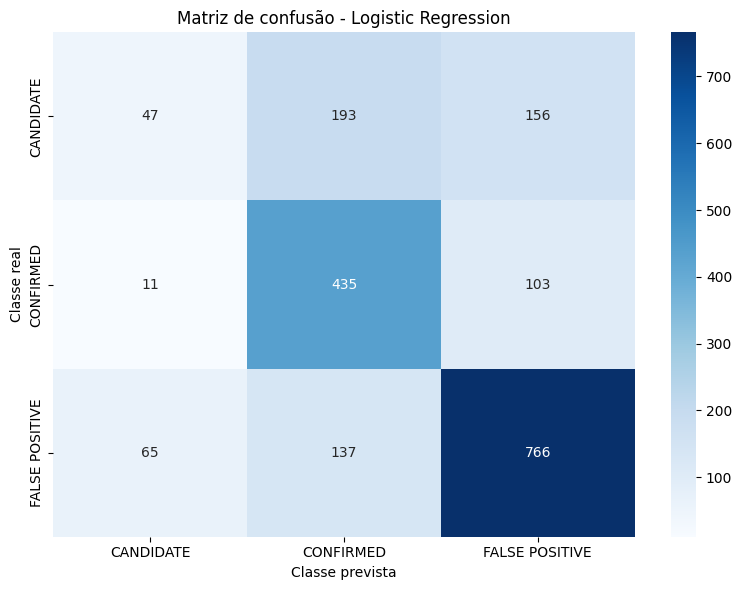

In [13]:
conf_matrix_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(8, 6))

sns.heatmap(
    conf_matrix_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Matriz de confusão - Logistic Regression")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")

plt.tight_layout()
plt.show()

### Análise da matriz de confusão do modelo Logistic Regression

A matriz de confusão mostra com mais clareza onde o modelo `Logistic Regression` está acertando e errando.

A classe `FALSE POSITIVE` foi a melhor identificada pelo modelo. Dos 968 exemplos reais dessa classe, 766 foram classificados corretamente. Isso confirma que o modelo consegue reconhecer melhor padrões associados a falsos positivos.

A classe `CONFIRMED` também teve um desempenho razoável. Dos 549 planetas confirmados, 435 foram classificados corretamente. Porém, ainda existem erros, principalmente casos confirmados sendo classificados como `FALSE POSITIVE`.

O maior problema aparece na classe `CANDIDATE`. Dos 396 candidatos reais, apenas 47 foram classificados corretamente. Muitos candidatos foram previstos como `CONFIRMED` ou `FALSE POSITIVE`.

Esse resultado indica que os candidatos ocupam uma região mais difícil de separar. Isso faz sentido, porque objetos candidatos ainda não têm uma confirmação definitiva e podem compartilhar características tanto com planetas confirmados quanto com falsos positivos.

Com isso, o modelo `Logistic Regression` funciona como baseline inicial, mas ainda não é suficiente para o objetivo do projeto. Nas próximas etapas, modelos mais flexíveis serão testados para tentar capturar padrões mais complexos nos dados.

### Treinamento do modelo Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

random_forest_model.fit(X_train, y_train)

y_pred_random_forest = random_forest_model.predict(X_test)

print("Modelo Random Forest treinado com sucesso.")

Modelo Random Forest treinado com sucesso.


In [15]:
y_pred_random_forest = random_forest_model.predict(X_test)

accuracy_random_forest = accuracy_score(y_test, y_pred_random_forest)

print("Accuracy:", round(accuracy_random_forest, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_random_forest, target_names=label_encoder.classes_))

Accuracy: 0.7778

Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.55      0.66      0.60       396
     CONFIRMED       0.81      0.83      0.82       549
FALSE POSITIVE       0.88      0.79      0.83       968

      accuracy                           0.78      1913
     macro avg       0.75      0.76      0.75      1913
  weighted avg       0.79      0.78      0.78      1913



### Análise do modelo Random Forest

O modelo `Random Forest` apresentou desempenho superior ao baseline com `Logistic Regression`.

A accuracy subiu de 65,24% para 77,78%, mostrando que o modelo conseguiu capturar melhor os padrões do dataset. Além disso, as métricas por classe ficaram mais equilibradas.

A maior melhora aparece na classe `CANDIDATE`. No modelo anterior, essa classe tinha F1-score de 0,18. Com `Random Forest`, o F1-score subiu para 0,60. Isso é um avanço importante para o projeto, porque os candidatos são objetos que ainda precisam de análise e podem ser relevantes para priorização.

A classe `CONFIRMED` também teve bom desempenho, com F1-score de 0,82. Já a classe `FALSE POSITIVE` manteve um resultado forte, com F1-score de 0,83.

Esse resultado indica que o `Random Forest` lida melhor com as relações não lineares entre as variáveis. Diferente da `Logistic Regression`, ele consegue combinar múltiplas condições e capturar padrões mais complexos nos dados.

Mesmo assim, ainda existe espaço para melhoria, principalmente na classe `CANDIDATE`, que continua sendo a mais difícil de classificar.

### Matriz de confusão do modelo Random Forest

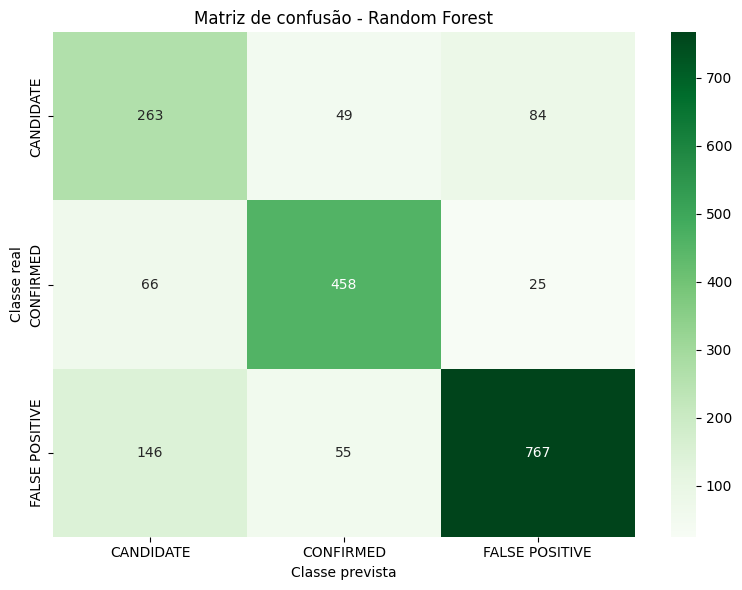

In [16]:
conf_matrix_random_forest = confusion_matrix(y_test, y_pred_random_forest)

plt.figure(figsize=(8, 6))

sns.heatmap(
    conf_matrix_random_forest,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Matriz de confusão - Random Forest")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")

plt.tight_layout()
plt.show()

### Análise da matriz de confusão do modelo Random Forest

A matriz de confusão do `Random Forest` mostra uma melhora clara em relação ao modelo `Logistic Regression`.

Na classe `CANDIDATE`, o modelo classificou corretamente 263 dos 396 exemplos. Esse resultado é bem superior ao baseline anterior, que havia acertado apenas 47 candidatos. Essa melhora é importante para o projeto, porque os candidatos representam objetos que ainda precisam de análise e podem ser priorizados para observações futuras.

A classe `CONFIRMED` também teve bom desempenho, com 458 acertos em 549 exemplos. Além disso, poucos planetas confirmados foram confundidos com `FALSE POSITIVE`, o que é positivo para evitar descartar objetos relevantes.

A classe `FALSE POSITIVE` continuou sendo bem identificada, com 767 acertos em 968 exemplos. Esse número é muito próximo do resultado da `Logistic Regression`, mas agora o modelo também apresenta um desempenho mais equilibrado nas outras classes.

Comparando com a matriz anterior, o `Random Forest` conseguiu distribuir melhor as previsões e reduziu a tendência de ignorar a classe `CANDIDATE`. Isso mostra que modelos não lineares conseguem lidar melhor com as relações entre as variáveis deste dataset.

Apesar da melhora, ainda existem erros relevantes. Por exemplo, 146 falsos positivos foram classificados como `CANDIDATE`, o que pode ser um problema em um sistema de priorização, pois poderia levar à análise de objetos menos promissores. Esse ponto será importante na comparação com os próximos modelos.

### Treinamento do modelo SVM

In [17]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("Modelo SVM treinado com sucesso.")

Modelo SVM treinado com sucesso.


In [18]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Accuracy:", round(accuracy_svm, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=label_encoder.classes_))

Accuracy: 0.6404

Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.37      0.45      0.41       396
     CONFIRMED       0.59      0.81      0.68       549
FALSE POSITIVE       0.90      0.62      0.74       968

      accuracy                           0.64      1913
     macro avg       0.62      0.63      0.61      1913
  weighted avg       0.70      0.64      0.65      1913



### Análise do modelo SVM

O modelo `SVM` apresentou accuracy de 64,04%, ficando abaixo do desempenho obtido pelo `Random Forest` e próximo ao baseline com `Logistic Regression`.

Apesar disso, o comportamento do SVM foi diferente. A classe `CANDIDATE` teve recall de 0,45, melhor do que o da `Logistic Regression`, mas ainda com precision baixa. Isso significa que o modelo conseguiu encontrar mais candidatos reais, mas também confundiu outros objetos com essa classe.

A classe `CONFIRMED` apresentou recall alto, de 0,81, indicando que muitos planetas confirmados foram identificados corretamente. Porém, o desempenho geral ainda não ficou tão equilibrado quanto no `Random Forest`.

A classe `FALSE POSITIVE` teve precision alta, de 0,90, mas recall menor, de 0,62. Isso significa que, quando o modelo prevê falso positivo, ele costuma acertar, mas deixa de identificar vários falsos positivos reais.

Esse resultado mostra que o SVM, nesta configuração inicial, não superou o `Random Forest`. Ainda assim, ele é importante para o projeto porque usa uma lógica baseada em margens e kernels, o que cria uma ponte conceitual com o experimento futuro de `Quantum Kernel`.

### Matriz de confusão do modelo SVM

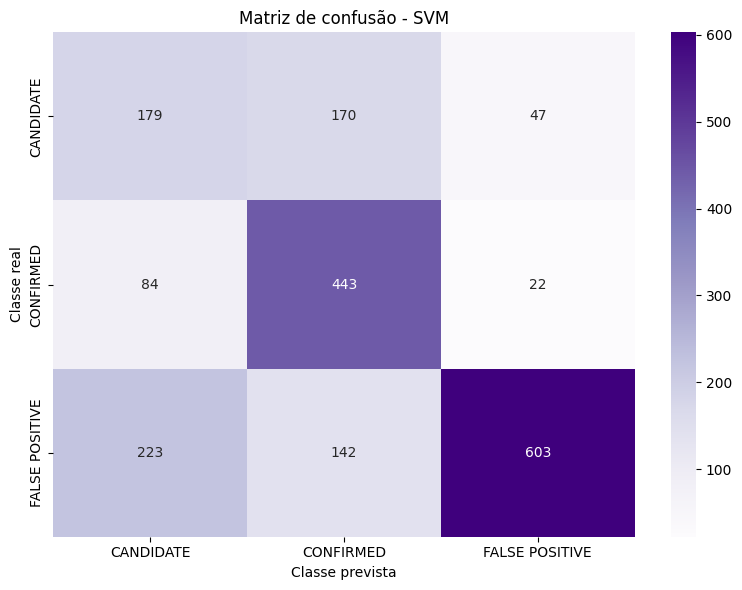

In [19]:
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8, 6))

sns.heatmap(
    conf_matrix_svm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Matriz de confusão - SVM")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")

plt.tight_layout()
plt.show()

### Análise da matriz de confusão do modelo SVM

A matriz de confusão do `SVM` mostra que o modelo teve um comportamento mais equilibrado para a classe `CANDIDATE` do que a `Logistic Regression`, mas ainda ficou abaixo do `Random Forest`.

Na classe `CANDIDATE`, o SVM acertou 179 dos 396 exemplos. Esse resultado é melhor do que o baseline inicial, mas ainda mostra muita confusão com a classe `CONFIRMED`, já que 170 candidatos foram previstos como confirmados.

Na classe `CONFIRMED`, o modelo teve bom número de acertos, com 443 classificações corretas em 549 exemplos. Porém, ainda houve confusão com `CANDIDATE`, o que mostra que essas duas classes possuem características parecidas no dataset.

Na classe `FALSE POSITIVE`, o modelo acertou 603 dos 968 exemplos. Apesar de esse número ser razoável, ele ficou abaixo do resultado do `Random Forest`, que havia acertado 767 falsos positivos.

De forma geral, o SVM conseguiu capturar parte dos padrões, mas não foi o melhor modelo nesta etapa. Seu principal valor no projeto está na comparação com o futuro experimento de `Quantum Kernel`, já que ambos trabalham com a ideia de transformar os dados para tentar separar melhor as classes.

### Comparação dos modelos baseline

In [20]:
model_results = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],
    "accuracy": [
        accuracy_logistic,
        accuracy_random_forest,
        accuracy_svm
    ]
})

model_results.sort_values("accuracy", ascending=False)

,model,accuracy
1,Random Forest,0.777836
0,Logistic Regression,0.652378
2,SVM,0.640355


### Análise da comparação dos modelos baseline

A comparação dos modelos mostra que o `Random Forest` apresentou o melhor desempenho entre os três modelos testados, com accuracy de aproximadamente 77,78%.

A `Logistic Regression` ficou em segundo lugar, com accuracy de aproximadamente 65,24%. Apesar de ser um modelo simples e útil como baseline inicial, ela teve dificuldade principalmente com a classe `CANDIDATE`.

O `SVM` apresentou accuracy de aproximadamente 64,04%, ficando abaixo dos demais nesta configuração inicial. Mesmo assim, ele continua sendo importante para o projeto por sua relação conceitual com métodos baseados em kernel, o que será útil na etapa futura de `Quantum Machine Learning`.

De forma geral, o resultado indica que modelos não lineares, como o `Random Forest`, conseguem lidar melhor com os padrões deste dataset. Esse modelo passa a ser a principal referência clássica para comparação com os próximos experimentos de Deep Learning.

### Importância das variáveis no modelo Random Forest

In [22]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values("importance", ascending=False)

feature_importance

,feature,importance
4,koi_model_snr,0.189709
5,koi_prad,0.127722
2,koi_depth,0.086063
0,koi_period,0.077848
1,koi_duration,0.072868
7,koi_insol,0.056312
6,koi_teq,0.051951
3,koi_num_transits,0.048190
8,koi_steff,0.046206
13,ra,0.044134


### Gráfico de importância das variáveis no Random Forest

### Análise da importância das variáveis no Random Forest

A análise de `feature importance` mostra quais variáveis tiveram maior peso nas decisões do modelo `Random Forest`.

A variável mais importante foi `koi_model_snr`, que representa a relação sinal-ruído. Isso faz sentido, porque a força do sinal observado é uma informação relevante para diferenciar objetos mais confiáveis de possíveis falsos positivos.

Em seguida aparecem `koi_prad`, `koi_depth`, `koi_period` e `koi_duration`. Essas variáveis estão ligadas ao tamanho estimado do possível planeta e ao comportamento do trânsito observado. Esse resultado reforça o que já havia sido observado na análise exploratória: características do trânsito e do possível planeta parecem ser importantes para separar as classes.

Também aparecem variáveis como `koi_insol`, `koi_teq` e `koi_num_transits`, que contribuem para a classificação, mas com menor peso.

Um ponto de atenção é que `ra` e `dec`, que representam a posição do objeto no céu, também aparecem com alguma importância. Como essas variáveis não descrevem diretamente o fenômeno físico do trânsito, será interessante avaliar em etapas futuras se vale mantê-las ou removê-las para evitar que o modelo aprenda padrões muito específicos da amostra.

De forma geral, o resultado confirma que o `Random Forest` está dando mais peso a variáveis com significado relevante para o problema, principalmente aquelas ligadas à qualidade do sinal e às propriedades estimadas do possível planeta.

### Salvamento dos resultados dos modelos baseline

In [24]:
model_results.to_csv("../data/processed/baseline_model_results.csv", index=False)

print("Resultados salvos em: ../data/processed/baseline_model_results.csv")

Resultados salvos em: ../data/processed/baseline_model_results.csv


### Conclusão dos modelos baseline

Neste notebook, foram preparados os dados para a primeira etapa de modelagem e treinados três modelos clássicos de Machine Learning: `Logistic Regression`, `Random Forest` e `SVM`.

Antes do treinamento, foram realizadas etapas importantes de preparação, como separação das variáveis de entrada e da variável-alvo, tratamento de valores ausentes com mediana, codificação da variável-alvo com `LabelEncoder`, divisão entre treino e teste e normalização das variáveis numéricas.

Entre os modelos testados, o `Random Forest` apresentou o melhor desempenho geral, com accuracy de aproximadamente 77,78%. Além disso, foi o modelo que melhor equilibrou os resultados entre as três classes, especialmente na identificação da classe `CANDIDATE`, que havia sido o principal ponto fraco da `Logistic Regression`.

A `Logistic Regression` cumpriu seu papel como baseline inicial, mas teve dificuldade em capturar padrões mais complexos do dataset, principalmente na classe `CANDIDATE`. Já o `SVM` apresentou desempenho inferior ao `Random Forest`, mas continua sendo relevante para o projeto por sua relação com métodos baseados em kernel, que serão retomados futuramente no experimento de `Quantum Machine Learning`.

A análise de importância das variáveis no `Random Forest` mostrou que `koi_model_snr`, `koi_prad`, `koi_depth`, `koi_period` e `koi_duration` foram algumas das variáveis mais relevantes para a classificação. Esse resultado é coerente com a análise exploratória, pois essas variáveis estão ligadas à qualidade do sinal observado, ao tamanho estimado do possível planeta e ao comportamento do trânsito.

Com base nesses resultados, o `Random Forest` será utilizado como principal referência clássica para comparação com os próximos modelos. A próxima etapa do projeto será desenvolver modelos de Deep Learning, começando por uma rede neural MLP e avançando depois para o uso de Autoencoder.